In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import xlabel, ylabel, title

In [59]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [60]:
file_path = r'plot_bar.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8',
    parse_dates=['日期']
)

df

,日期,手机销量,耳机销量,卫衣销量,城市
0,2024-05-01,20,15,80,北京
1,2024-05-02,25,18,75,北京
2,2024-05-03,18,12,90,北京
3,2024-05-04,30,20,85,北京
4,2024-05-05,22,16,78,北京


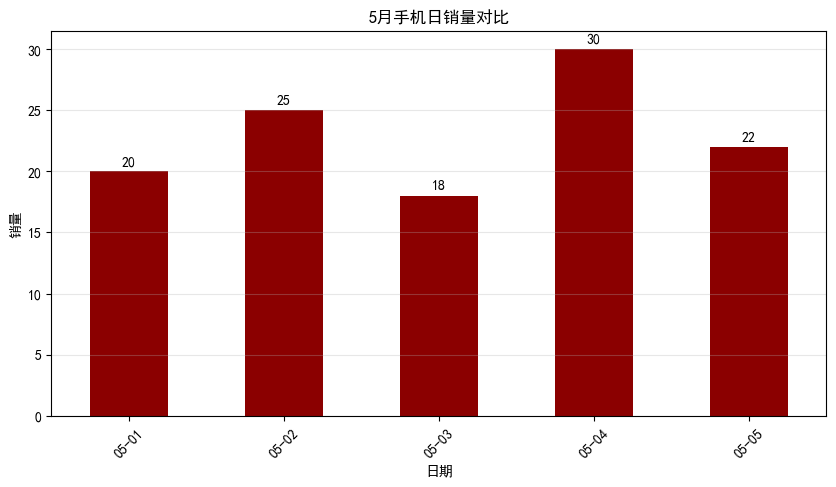

In [61]:
df['手机销量'].plot(
    kind='bar',
    figsize=(10, 5),
    title='5月手机日销量对比',
    xlabel='日期',
    ylabel='销量',
    color='darkred'
)

for i, v in enumerate(df['手机销量']):
    plt.text(i, v+0.5, str(v), ha='center')

plt.xticks(df.index, df['日期'].dt.strftime('%m-%d'), rotation=45) # 日期格式化
plt.grid(axis='y', alpha=0.3)
plt.show()

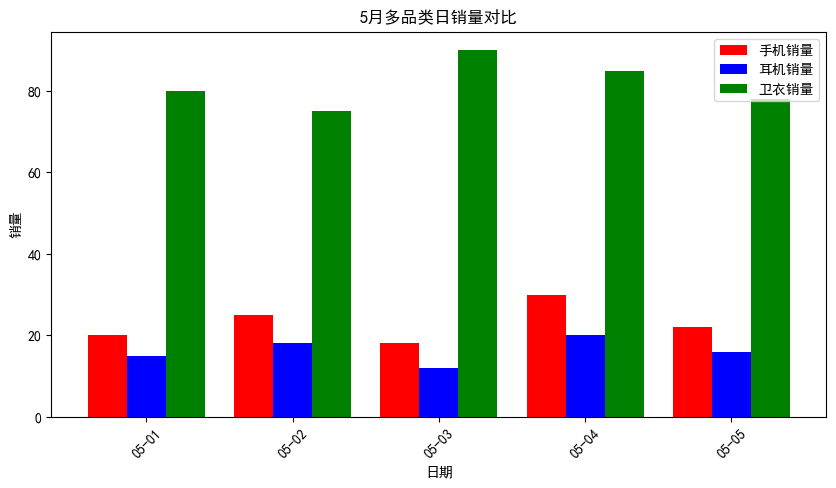

In [62]:
df[['手机销量', '耳机销量', '卫衣销量']].plot(
    kind='bar',
    figsize=(10, 5),
    title='5月多品类日销量对比',
    color=['red', 'blue', 'green'],
    width=0.8,
    xlabel='日期',
    ylabel='销量'
)

plt.xticks(df.index, df['日期'].dt.strftime('%m-%d'), rotation=45) # 日期格式化
plt.legend(loc='upper right')
plt.show()

In [63]:
df

,日期,手机销量,耳机销量,卫衣销量,城市
0,2024-05-01,20,15,80,北京
1,2024-05-02,25,18,75,北京
2,2024-05-03,18,12,90,北京
3,2024-05-04,30,20,85,北京
4,2024-05-05,22,16,78,北京


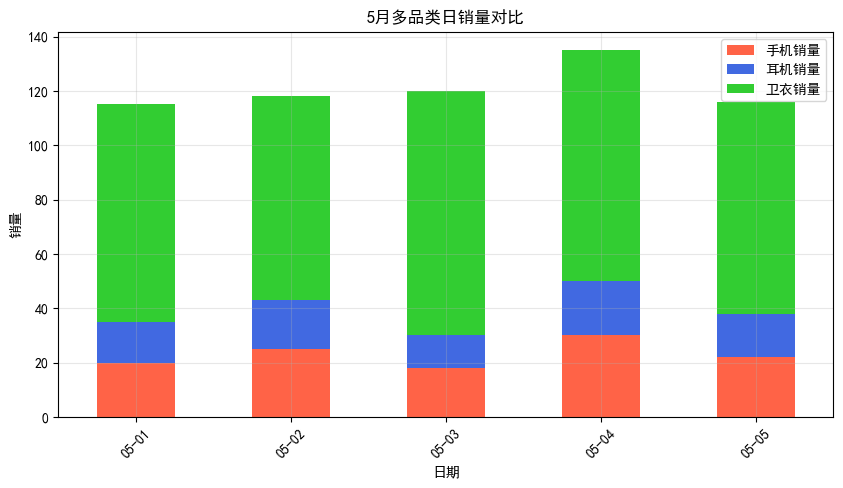

In [64]:
df[['手机销量', '耳机销量', '卫衣销量']].plot(
    kind='bar',
    figsize=(10, 5),
    title='5月多品类日销量对比',
    color=['#FF6347', '#4169E1', '#32CD32'],
    xlabel='日期',
    ylabel='销量',
    stacked=True
)

plt.grid(alpha=0.3)
plt.xticks(df.index, df['日期'].dt.strftime('%m-%d'), rotation=45) # 日期格式化
plt.legend(loc='upper right')
plt.show()

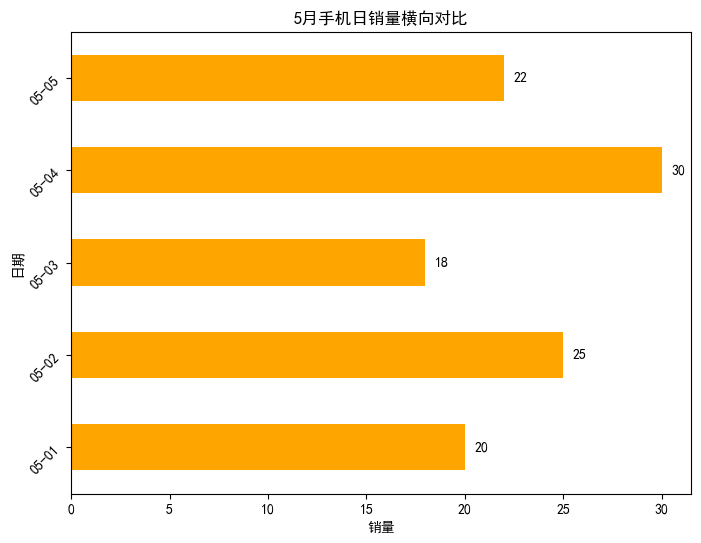

In [65]:
df['手机销量'].plot(
    kind='barh',
    figsize=(8, 6),
    title='5月手机日销量横向对比',
    color='orange',
    xlabel='销量',
    ylabel='日期'
)

for i, v in enumerate(df['手机销量']):
    plt.text(v+0.5, i, str(v), va='center')

plt.yticks(df.index, df['日期'].dt.strftime('%m-%d'), rotation=45) # 日期格式化
# plt.grid(axis='y', alpha=0.3)
plt.show()

In [66]:
df_multi = df.reset_index(drop=True)
df_multi['城市'] = '北京'
df_sh = df_multi.copy()
df_sh['城市'] = '上海'
df_sh['手机销量'] = [18,22,16,28,20]
df_sh['耳机销量'] = [13,16,10,18,14]
df_multi = pd.concat([df_multi, df_sh])

df_multi

,日期,手机销量,耳机销量,卫衣销量,城市
0,2024-05-01,20,15,80,北京
1,2024-05-02,25,18,75,北京
2,2024-05-03,18,12,90,北京
3,2024-05-04,30,20,85,北京
4,2024-05-05,22,16,78,北京
0,2024-05-01,18,13,80,上海
1,2024-05-02,22,16,75,上海
2,2024-05-03,16,10,90,上海
3,2024-05-04,28,18,85,上海
4,2024-05-05,20,14,78,上海


In [67]:
df_pivot = df_multi.pivot(index='日期', columns='城市', values='手机销量')
df_pivot

城市,上海,北京
日期,,
2024-05-01,18,20
2024-05-02,22,25
2024-05-03,16,18
2024-05-04,28,30
2024-05-05,20,22


In [68]:
df_pivot = df_pivot.reset_index()
df_pivot

城市,日期,上海,北京
0,2024-05-01,18,20
1,2024-05-02,22,25
2,2024-05-03,16,18
3,2024-05-04,28,30
4,2024-05-05,20,22


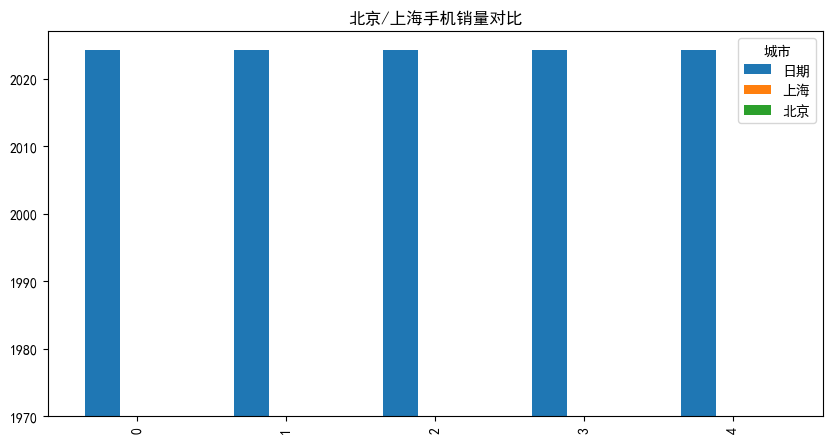

In [69]:
df_pivot.plot(
    kind='bar',
    figsize=(10, 5),
    title='北京/上海手机销量对比',
    width=0.7
)

plt.show()

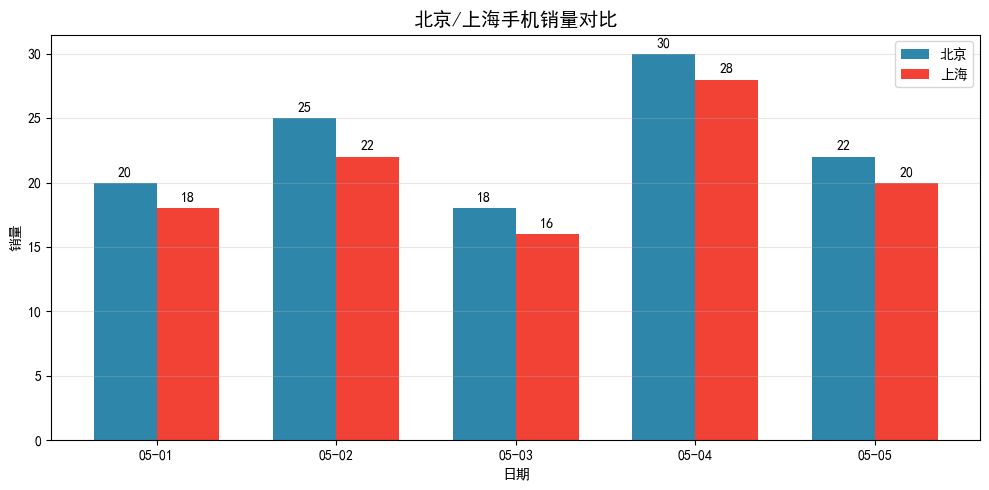

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
file_path = r'plot_bar.csv'
df = pd.read_csv(
    file_path,
    encoding='utf-8',
    parse_dates=['日期'],
    index_col='日期'
)

# ================= 修复这里！不要 drop=True！=================
df_multi = df.reset_index()  # 这里必须去掉 drop=True！
# ===========================================================

df_multi['城市'] = '北京'

# 构造上海数据
df_sh = df_multi.copy()
df_sh['城市'] = '上海'
df_sh['手机销量'] = [18,22,16,28,20]
df_sh['耳机销量'] = [13,16,10,18,14]

df_multi = pd.concat([df_multi, df_sh])

# 透视表
df_pivot = df_multi.pivot(index='日期', columns='城市', values='手机销量')

# 绘图（完全正确）
plt.figure(figsize=(10,5))
bar_width = 0.35
x = range(len(df_pivot))

plt.bar([i-bar_width/2 for i in x], df_pivot['北京'], width=bar_width, label='北京', color='#2E86AB')
plt.bar([i+bar_width/2 for i in x], df_pivot['上海'], width=bar_width, label='上海', color='#F24236')

plt.xticks(x, df_pivot.index.strftime('%m-%d'), rotation=0)
plt.title('北京/上海手机销量对比', fontsize=14)
plt.xlabel('日期')
plt.ylabel('销量')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 加数值
for i,(bj,sh) in enumerate(zip(df_pivot['北京'], df_pivot['上海'])):
    plt.text(i-bar_width/2, bj+0.5, str(bj), ha='center')
    plt.text(i+bar_width/2, sh+0.5, str(sh), ha='center')

plt.tight_layout()
plt.show()

In [71]:
df

,手机销量,耳机销量,卫衣销量,城市
日期,,,,
2024-05-01,20,15,80,北京
2024-05-02,25,18,75,北京
2024-05-03,18,12,90,北京
2024-05-04,30,20,85,北京
2024-05-05,22,16,78,北京


In [78]:
df_null = df.copy()
df_null

,手机销量,耳机销量,卫衣销量,城市
日期,,,,
2024-05-01,20,15,80,北京
2024-05-02,25,18,75,北京
2024-05-03,18,12,90,北京
2024-05-04,30,20,85,北京
2024-05-05,22,16,78,北京


In [79]:
df_null.loc['2024-05-03', '耳机销量'] = 0
df_null

,手机销量,耳机销量,卫衣销量,城市
日期,,,,
2024-05-01,20,15,80,北京
2024-05-02,25,18,75,北京
2024-05-03,18,0,90,北京
2024-05-04,30,20,85,北京
2024-05-05,22,16,78,北京


In [80]:
df_null = df_null.reset_index()

df_null

,日期,手机销量,耳机销量,卫衣销量,城市
0,2024-05-01,20,15,80,北京
1,2024-05-02,25,18,75,北京
2,2024-05-03,18,0,90,北京
3,2024-05-04,30,20,85,北京
4,2024-05-05,22,16,78,北京


In [89]:
df

,手机销量,耳机销量,卫衣销量,城市
日期,,,,
2024-05-01,20,15,80,北京
2024-05-02,25,18,75,北京
2024-05-03,18,12,90,北京
2024-05-04,30,20,85,北京
2024-05-05,22,16,78,北京


In [100]:
df_null

,日期,手机销量,耳机销量,卫衣销量,城市
0,2024-05-01,20,15,80,北京
1,2024-05-02,25,18,75,北京
2,2024-05-03,18,0,90,北京
3,2024-05-04,30,20,85,北京
4,2024-05-05,22,16,78,北京


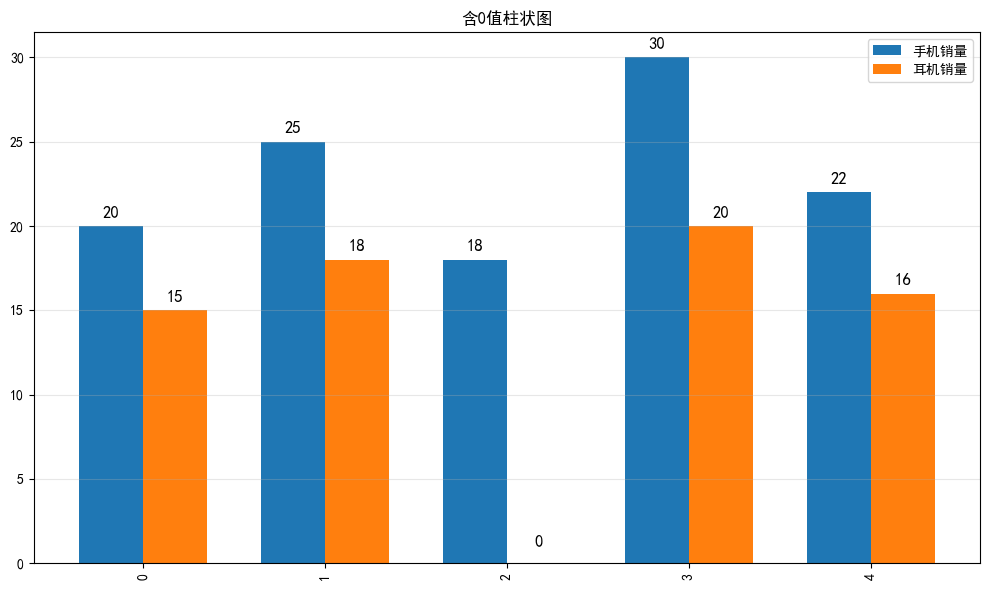

In [103]:
# 绘图（先reset_index，避免日期bug）
df_plot = df_null[["手机销量", "耳机销量"]]
ax = df_plot.plot(
    kind="bar",
    title="含0值柱状图",
    figsize=(10, 6),
    width=0.7
)

# 正确标注数值（核心修复！）
bar_width = 0.35
x = range(len(df_plot))

# 标注手机销量（左柱子）
for i, v in enumerate(df_plot["手机销量"]):
    ax.text(i - bar_width/2, v + 0.5, str(v), ha="center", fontsize=12)

# 标注耳机销量（右柱子，0值特殊处理）
for i, v in enumerate(df_plot["耳机销量"]):
    if v > 0:
        ax.text(i + bar_width/2, v + 0.5, str(v), ha="center", fontsize=12)
    else:
        ax.text(i + bar_width/2, 1, "0", ha="center", fontsize=12)  # 0值上移

# 美化x轴
# plt.xticks(rotation=45)
# plt.xticks(df.index, df_null['日期'].dt.strftime('%m-%d'), rotation=45) # 日期格式化
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()